# Goal:

This notebook is part of a series of tests that we want to perform to make sure out reconstruction algorithm is working as expected.

Here, we will run a 2Q-GST reconstruction where the true gate set (the one we aim to reconstruct) is the target gate set (the one without noise), and the initialization for the optimization is the target + perturbation.

We expect, if everything is correct, for this to be an easy test for the GST algorihtm

In [53]:
from mGST.utility_functions_comparisons import get_compressed_rep_from_mgst_output, get_compressed_perturbed_rep_from_mgst, create_2q_emerald_gst_config, get_compressed_perturbed_kraus_from_superop

from mGST.gauge_analysis import max_num_parameters, min_num_parameters
from mGST.simulate import generate_sequence_indices, compute_probability_matrices
from mGST.low_level_jit import cost_function_jax_mps
from mGST.typing import OperatorSchedule, TrustRegionOptions
from mGST.trust_region import run_riemannian_optimization, estimate_noise_floor_threshold
from mGST.visualization import plot_cost_function

import jax.numpy as jnp
import pickle

backend = "iqmfakeapollo"
data_path = "../data/"

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Setup

We use the 2Q tensors from some emerald data for ease.

## Import tensors

In [ ]:
# from mGST.utility_functions_comparisons import GSTConfiguration
# Try to get 
# num_shots = 1000
# num_sequences = 1000
# kraus_rank = 4

# Q2_GST = GSTConfiguration(
#     qubit_layouts=[[0, 1]],
#     gate_set="2QXYICZ",
#     num_circuits=num_sequences,
#     shots=num_shots,
#     rank=kraus_rank,
# )

In [11]:
Q2_GST_EMERALD = create_2q_emerald_gst_config()

with open(data_path +'emerald_2q_parallel_qubits_44__48.pkl', 'rb') as function:
    data = pickle.load(function)
    
kraus_tensor_target = data["K_target"]
kraus_superop_target = data["X_target"]
povm_vect_target = data["E_target"]
state_vect_target = data["rho_target"]

# dimensions
dim = kraus_tensor_target.shape[-1]
num_povm = povm_vect_target.shape[0]
num_gates = kraus_tensor_target.shape[0]

# Getting the target representations in compressed form
kraus_tensor_2q_target, povm_psd_2q_target, state_psd_2q_target = get_compressed_rep_from_mgst_output(kraus_superop_target, povm_vect_target, state_vect_target, kraus_rank=dim**2, state_rank=dim, povm_rank=dim)

# Testing they are all correct
povm_jax_target = povm_psd_2q_target.conj().transpose(0, 2, 1) @ povm_psd_2q_target
superop_kraus_test = jnp.einsum("ijkl,ijnm -> iknlm", kraus_tensor_2q_target, kraus_tensor_2q_target.conj()).reshape((num_gates, dim**2, dim**2))

rho_target_matrix = state_vect_target.reshape(dim, dim)
povm_target_matrices = povm_vect_target.reshape(num_povm, dim, dim)

jnp.allclose(state_psd_2q_target @ state_psd_2q_target.conj().T, rho_target_matrix), jnp.allclose(povm_jax_target, povm_target_matrices), jnp.allclose(superop_kraus_test, kraus_superop_target)

(Array(True, dtype=bool), Array(True, dtype=bool), Array(True, dtype=bool))

## Initial tensors

In [ ]:
kraus_rank = dim
povm_rank = dim
state_rank = dim

kraus_tensor_init_dict = get_compressed_perturbed_kraus_from_superop(superop=kraus_superop_target, rank=kraus_rank, seed=42)
kraus_tensor_init = kraus_tensor_init_dict["kraus_tensor"]

povm_psd_init_jax, state_psd_init_jax = get_compressed_perturbed_rep_from_mgst(povm_vect_target, state_vect_target, rank_povm=povm_rank, rank_state=state_rank)

init_operators = {
    "kraus_tensor_init": kraus_tensor_init,
    "povm_psd_init": povm_psd_init_jax,
    "state_psd_init": state_psd_init_jax,
}

print(f"shapes: {[v.shape for v in init_operators.values()]}")

shapes: [(7, 4, 4, 4), (4, 4, 4), (4, 4)]


In [22]:
# what are the max and min number of parameters for this configuration?
upper_bound = max_num_parameters(num_qubits=2, num_gates=num_gates, kraus_rank=kraus_rank, state_rank=state_rank, povm_rank=povm_rank)
lower_bound = min_num_parameters(num_qubits=2, num_gates=num_gates, kraus_rank=kraus_rank, state_rank=state_rank, povm_rank=povm_rank)

print(f"Upper bound: {upper_bound}, Lower bound: {lower_bound}")

Upper bound: 927, Lower bound: 719


In [26]:
# now let's obtai the sequence indices and probability samples
num_shots = 1000
num_sequences = 1000
seq_len_list = [1, 8, 14]

indices_list = generate_sequence_indices(num_gates=num_gates, num_circuits=num_sequences, seq_len_list=seq_len_list)

probability_matrices = compute_probability_matrices(kraus_tensor=kraus_tensor_2q_target, povm_psd=povm_psd_2q_target, state_psd=state_psd_2q_target, gate_indices=indices_list, num_shots=num_shots, seed=42)

In [27]:
probability_matrices

{'exact': Array([[1.00000000e+00, 5.00000000e-01, 2.50000000e-01, ...,
         2.50000000e-01, 2.50000000e-01, 2.50000000e-01],
        [0.00000000e+00, 5.00000000e-01, 2.50000000e-01, ...,
         2.50000000e-01, 2.50000000e-01, 2.50000000e-01],
        [0.00000000e+00, 7.50805213e-34, 2.50000000e-01, ...,
         2.50000000e-01, 2.50000000e-01, 2.50000000e-01],
        [0.00000000e+00, 8.94363413e-34, 2.50000000e-01, ...,
         2.50000000e-01, 2.50000000e-01, 2.50000000e-01]], dtype=float64),
 'sampled': array([[1.   , 0.508, 0.228, ..., 0.256, 0.232, 0.263],
        [0.   , 0.492, 0.251, ..., 0.249, 0.273, 0.258],
        [0.   , 0.   , 0.269, ..., 0.235, 0.257, 0.261],
        [0.   , 0.   , 0.252, ..., 0.26 , 0.238, 0.218]])}

In [37]:
prob_matrix = probability_matrices["sampled"]
cost_fn_kwargs = {
    "indices_list": indices_list,
    "prob_matrix": prob_matrix,
    "jit": True,
}

# Initial cost

In [30]:
initial_cost_value = cost_function_jax_mps(*init_operators.values(), **cost_fn_kwargs)
print("Initial cost value:", initial_cost_value)

at iteration 0 the new count changed to: 1
at iteration 1 the new count changed to: 2
at iteration 8 the new count changed to: 3
at iteration 57 the new count changed to: 4
at iteration 130 the new count changed to: 5
at iteration 204 the new count changed to: 6
at iteration 278 the new count changed to: 7
at iteration 352 the new count changed to: 8
at iteration 426 the new count changed to: 9
at iteration 500 the new count changed to: 10
at iteration 583 the new count changed to: 11
at iteration 666 the new count changed to: 12
at iteration 749 the new count changed to: 13
at iteration 832 the new count changed to: 14
at iteration 916 the new count changed to: 15
Initial cost value: 0.0011015038954847497


In [90]:
from mGST.simulate import get_perturbed_compressed_state_tensor, get_perturbed_compressed_povm_tensor

perturbation_strength = 1e-1
povm_psd_perturbed = get_perturbed_compressed_povm_tensor(povm_vect_target.reshape(num_povm, dim, dim), rank=povm_rank, epsilon=perturbation_strength, seed=42)

state_psd_perturbed = get_perturbed_compressed_state_tensor(state_vect_target.reshape(dim, dim), rank=state_rank, epsilon=perturbation_strength, seed=42)

perturbed_operators = {
    "kraus": kraus_tensor_init,
    "povm": povm_psd_perturbed,
    "state": state_psd_perturbed,
}

initial_cost_value_perturbed = cost_function_jax_mps(*perturbed_operators.values(), **cost_fn_kwargs)
print("Initial cost value (perturbed):", initial_cost_value_perturbed)

Initial cost value (perturbed): 0.0013176391428131


In [91]:
[op.shape for op in perturbed_operators.values()]

[(7, 4, 4, 4), (4, 4, 4), (4, 4)]

# Optimization

In [35]:
num_iterations_outer = 5
num_iterations_tr = 10
num_iterations_cg = 10
tol_grad = 1e-4
kappa = 1/10
theta = 1 # before by mistake we set it to 0.5 (WRONG)

tr_schedule_verbose = OperatorSchedule.default(num_iterations_outer, TrustRegionOptions(num_iterations=num_iterations_tr, verbose=True, verbose_cg=True, num_iterations_cg=num_iterations_cg, tol_grad=tol_grad, kappa_cg=kappa, theta_cg=theta))

relative_precision = 1e-5

optimization_schedule_all_tr = {
    "kraus": tr_schedule_verbose,
    "povm": tr_schedule_verbose,
    "state": tr_schedule_verbose
}
optimization_schedule_all_tr

{'kraus': OperatorSchedule(items=[OptimizationScheduleItem(start=0, end=4, options=TrustRegionOptions(metric='euclidean', verbose=True, num_iterations=10, radius_init=0.1, max_radius=2.0, quotient_trust=0.125, tol_grad=0.0001, num_iterations_cg=10, theta_cg=1, kappa_cg=0.1, verbose_cg=True))]),
 'povm': OperatorSchedule(items=[OptimizationScheduleItem(start=0, end=4, options=TrustRegionOptions(metric='euclidean', verbose=True, num_iterations=10, radius_init=0.1, max_radius=2.0, quotient_trust=0.125, tol_grad=0.0001, num_iterations_cg=10, theta_cg=1, kappa_cg=0.1, verbose_cg=True))]),
 'state': OperatorSchedule(items=[OptimizationScheduleItem(start=0, end=4, options=TrustRegionOptions(metric='euclidean', verbose=True, num_iterations=10, radius_init=0.1, max_radius=2.0, quotient_trust=0.125, tol_grad=0.0001, num_iterations_cg=10, theta_cg=1, kappa_cg=0.1, verbose_cg=True))])}

In [40]:
noise_floor = estimate_noise_floor_threshold(probability_matrix=prob_matrix, num_shots=num_shots, multiplier=1.0)
noise_floor

Array(0.00013874, dtype=float64)

In [ ]:
optimized_operators, cost_fn_history = run_riemannian_optimization(
    **init_operators,
    cost_function=cost_function_jax_mps,
    cost_fn_kwargs=cost_fn_kwargs,
    num_iterations=num_iterations_outer,
    optimization_schedule=optimization_schedule_all_tr,
    save_intermediate_cost_values=True,
    noise_threshold=None,
    relative_precision=relative_precision,
    verbose=True,
)
# 14m 45.7s

🔰 Starting Riemannian Optimization 🔰 
 * optimization schedule: 
kraus: Schedule:
  [0-4]: TrustRegionOptions
povm: Schedule:
  [0-4]: TrustRegionOptions
state: Schedule:
  [0-4]: TrustRegionOptions 
* Convergence Criteria: 
+ Relative Precision 📏 1.00e-05 
+ Gradient(s) Norm(s) 📐
🚀 TR started for operator: povm 🚀.
TR Iteration: 0. f(x): 1.101504e-03. |r∇f(x)|: 5.031888e-03. Radius: 1.00e-01
TCG finished after: 2/10 iters. 
 Reason: Exceeded trust region boundary 📈.
---------------------------------------
TR Iteration: 1. f(x): 8.525493e-04. |r∇f(x)|: 1.964911e-04. Radius: 2.00e-01
TCG finished after: 9/10 iters. 
 Reason: Negative curvature encountered 📉.
---------------------------------------
TR Iteration: 2. f(x): 8.520376e-04. |r∇f(x)|: 1.156011e-05. Radius: 4.00e-01
TCG finished after: 10/10 iters. 
 Reason: Max iterations reached ⏳.
---------------------------------------
(RTR) Stopping criteria met. 🚨 |r∇f(x)|/|r∇f(x_0)| = 6.643456e-05
Optimization finished ✅. 
 Iters: 3. f(x):

In [93]:
optimized_operators_perturbed, cost_fn_history_perturbed = run_riemannian_optimization(
    *perturbed_operators.values(),
    cost_function=cost_function_jax_mps,
    cost_fn_kwargs=cost_fn_kwargs,
    num_iterations=num_iterations_outer,
    optimization_schedule=optimization_schedule_all_tr,
    save_intermediate_cost_values=True,
    noise_threshold=None,
    relative_precision=relative_precision,
    verbose=True,
)

🔰 Starting Riemannian Optimization 🔰 
 * optimization schedule: 
kraus: Schedule:
  [0-4]: TrustRegionOptions
povm: Schedule:
  [0-4]: TrustRegionOptions
state: Schedule:
  [0-4]: TrustRegionOptions 
* Convergence Criteria: 
+ Relative Precision 📏 1.00e-05 
+ Gradient(s) Norm(s) 📐
🚀 TR started for operator: povm 🚀.
TR Iteration: 0. f(x): 1.317639e-03. |r∇f(x)|: 5.428758e-03. Radius: 1.00e-01
TCG finished after: 1/10 iters. 
 Reason: Exceeded trust region boundary 📈.
---------------------------------------
TR Iteration: 1. f(x): 1.011207e-03. |r∇f(x)|: 1.200341e-03. Radius: 2.00e-01
TCG finished after: 10/10 iters. 
 Reason: Exceeded trust region boundary 📈.
---------------------------------------
TR Iteration: 2. f(x): 9.910409e-04. |r∇f(x)|: 3.686257e-04. Radius: 4.00e-01
TCG finished after: 10/10 iters. 
 Reason: Max iterations reached ⏳.
---------------------------------------
TR Iteration: 3. f(x): 9.861756e-04. |r∇f(x)|: 5.306678e-05. Radius: 4.00e-01
TCG finished after: 10/10 ite

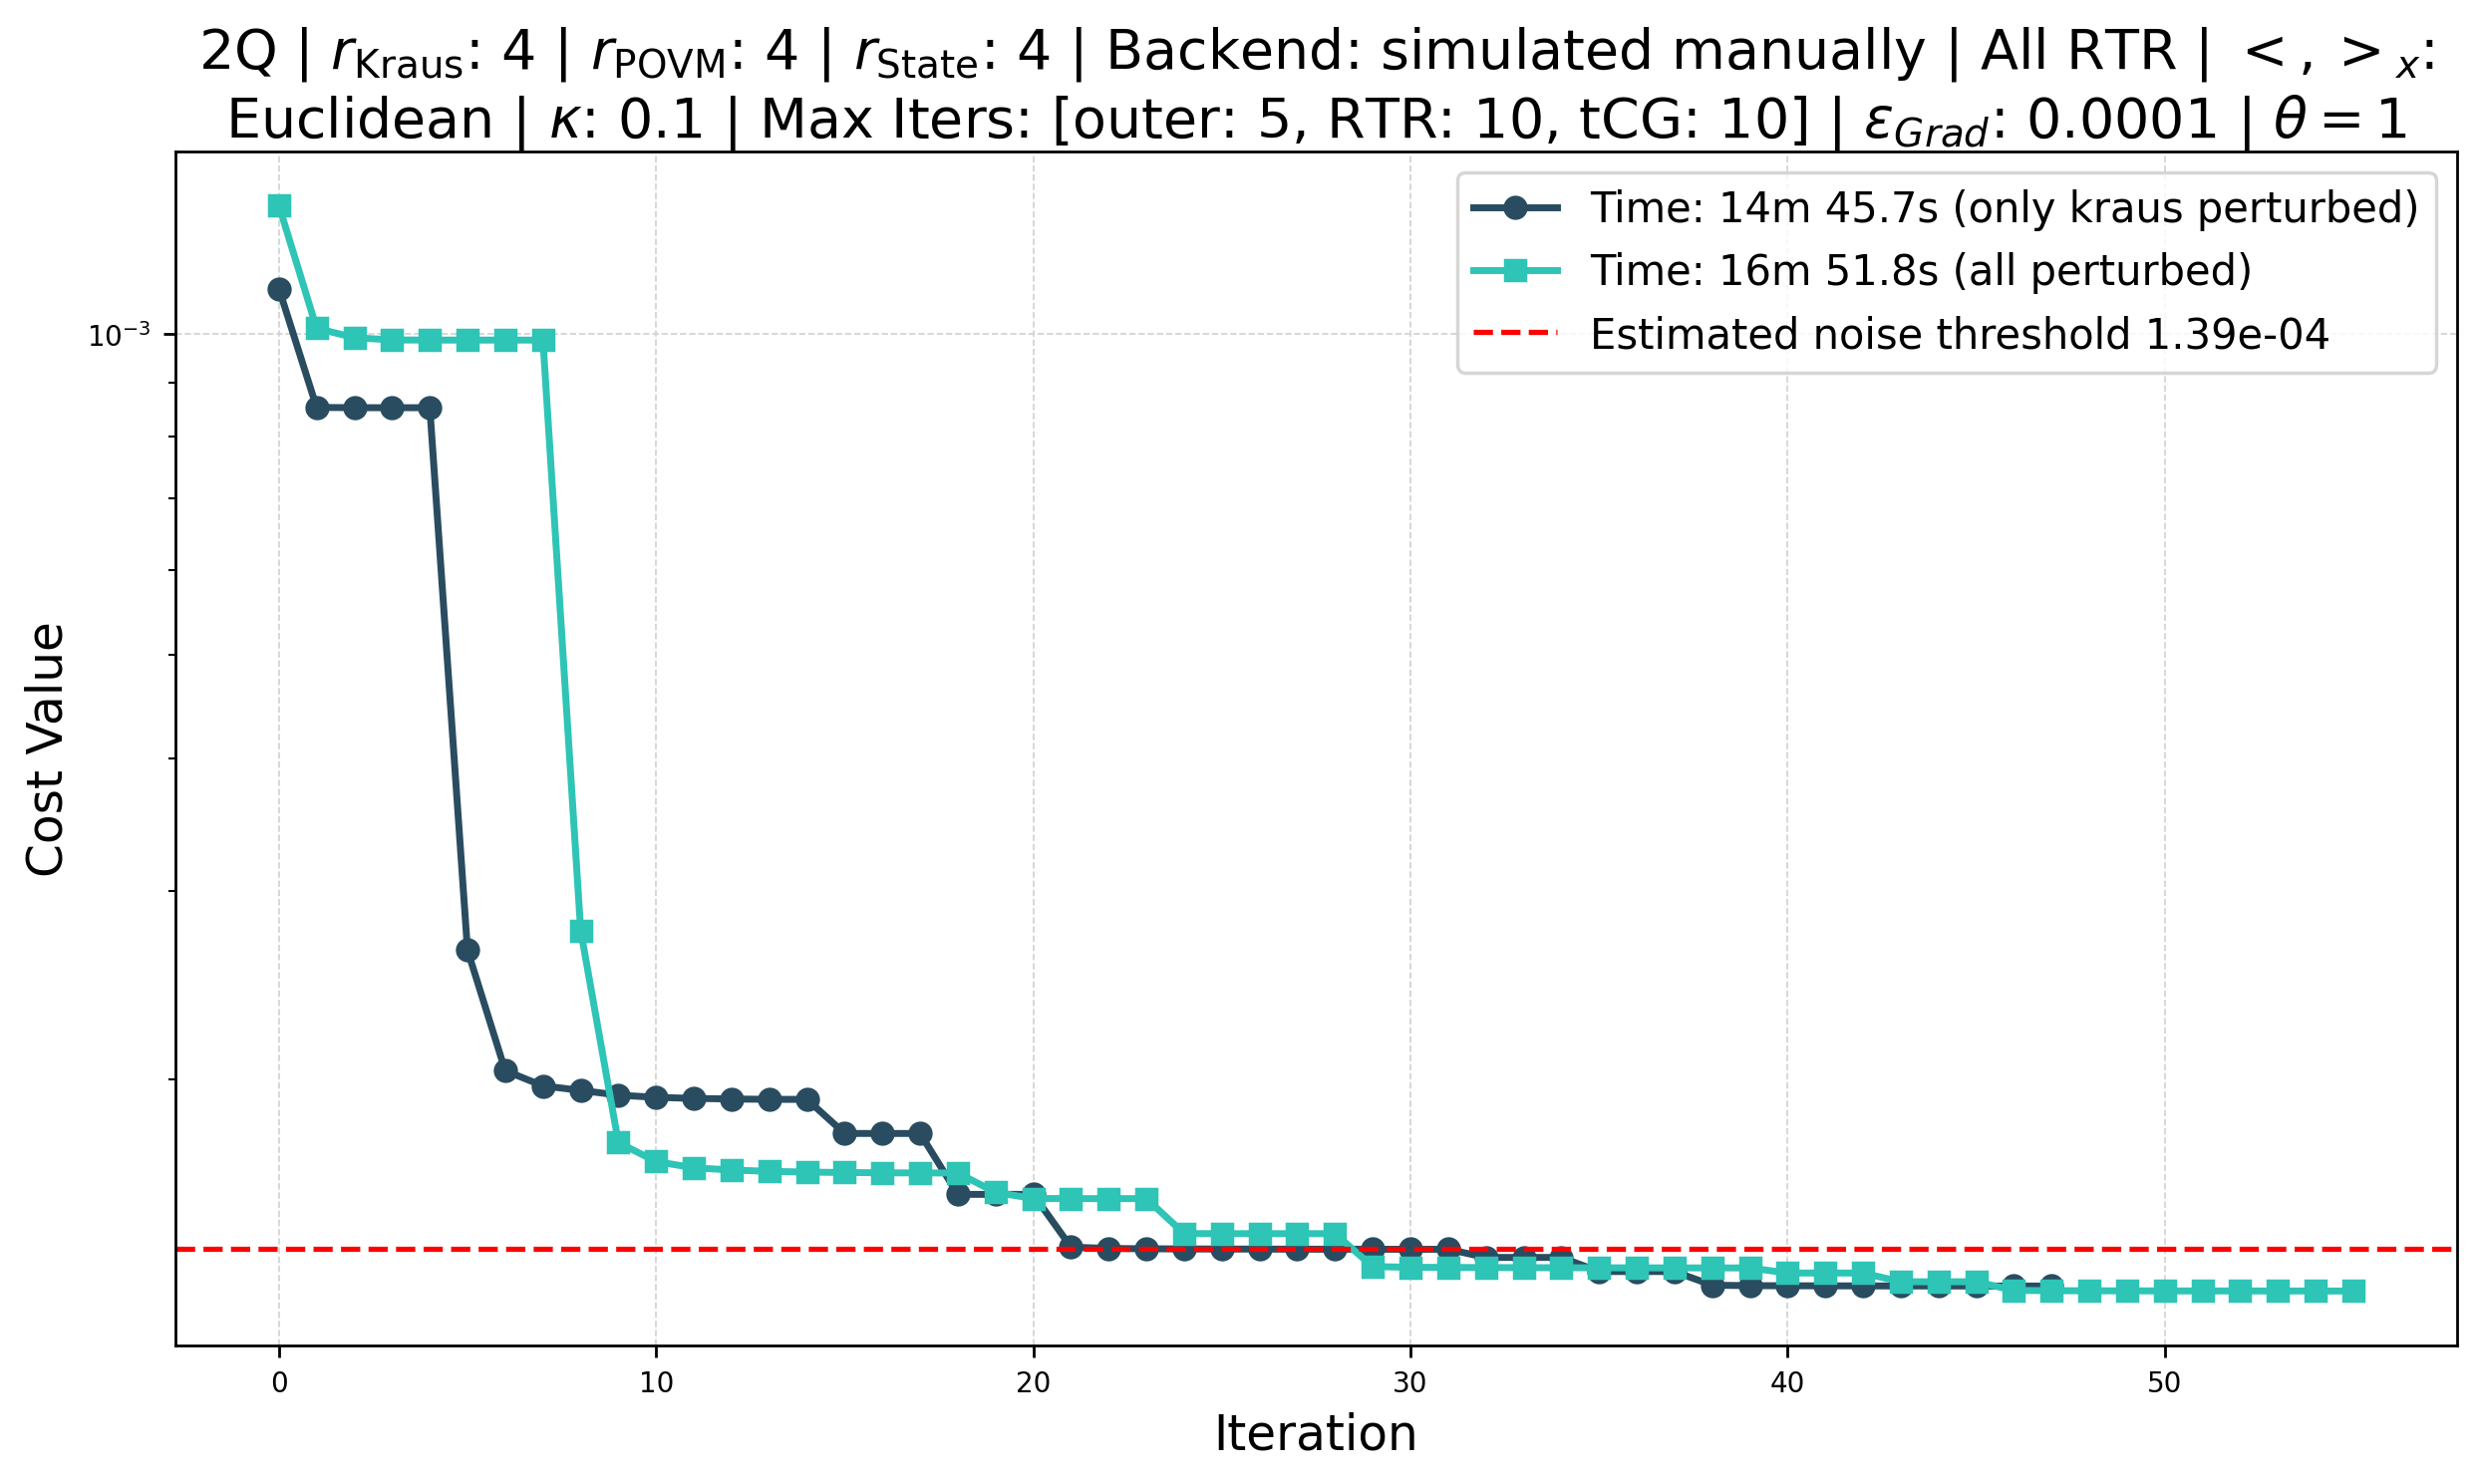

In [97]:
cost_fn_lists_ranks = [
    cost_fn_history,
    cost_fn_history_perturbed
]

time = "14m 45.7s"
time_perturbed = "16m 51.8s"
labels_ranks = [
    rf"Time: {time} (only kraus perturbed)",
    rf"Time: {time_perturbed} (all perturbed)",
]

title_ranks = rf"2Q | $r_\mathrm{{Kraus}}$: {kraus_rank} | $r_\mathrm{{POVM}}$: {povm_rank} | $r_\mathrm{{State}}$: {state_rank} | Backend: simulated manually | All RTR | $<,>_x$: Euclidean | $\kappa$: {kappa} | Max Iters: [outer: {num_iterations_outer}, RTR: {num_iterations_tr}, tCG: {num_iterations_cg}] | $\epsilon_{{Grad}}$: {tol_grad} | $\theta=${theta}"

plot_cost_function(cost_fn_lists_ranks, title=title_ranks, labels=labels_ranks, comparison_yline=noise_floor, comparison_label=f"Estimated noise threshold {noise_floor:.2e}")

In [62]:
optimized_operators.keys()

dict_keys(['kraus', 'povm', 'state'])

In [78]:
cost_fn_history[0], cost_fn_history[-1]

(Array(0.0011015, dtype=float64), Array(0.00012803, dtype=float64))

In [98]:
cost_fn_history_perturbed[0], cost_fn_history_perturbed[-1]

(Array(0.00131764, dtype=float64), Array(0.00012666, dtype=float64))

# Gauge optimization

In [61]:
from mGST.reporting.reporting import gauge_opt
from mGST.compatibility import arrays_to_pygsti_model
from mGST.utility_functions_comparisons import get_mgst_tensors_from_psd_representation

In [60]:
# The target model is the mgst tensors obtained in the beginning without perturbation
target_ops = {
    "X": kraus_superop_target,
    "E": povm_vect_target,
    "rho": state_vect_target
}
target_model_pygsti = arrays_to_pygsti_model(**target_ops, basis="std")
gauge_weights = dict({f"G%i" % i: 1 for i in range(num_gates)}, **{"spam": 0.1})

In [64]:
optimized_superops = get_mgst_tensors_from_psd_representation(*optimized_operators.values())
optimized_superops.keys()

kraus_superop_gauged, povm_vect_gauged, state_vect_gauged = gauge_opt(X=optimized_superops["kraus"], E=optimized_superops["povm"], rho=optimized_superops["state"], target_mdl=target_model_pygsti, weights=gauge_weights)

In [99]:
optimized_superops_perturbed = get_mgst_tensors_from_psd_representation(*optimized_operators_perturbed.values())
optimized_superops_perturbed.keys()

kraus_superop_gauged_perturbed, povm_vect_gauged_perturbed, state_vect_gauged_perturbed = gauge_opt(X=optimized_superops_perturbed["kraus"], E=optimized_superops_perturbed["povm"], rho=optimized_superops_perturbed["state"], target_mdl=target_model_pygsti, weights=gauge_weights)

# Compute error metrics

In [65]:
from mGST.reporting.reporting import report

In [72]:
# we don't know the exat labels so just create some
gate_labels = {idx:f"G-{idx}" for idx in range(num_gates)}
gate_labels

indices_list_with_negatives = generate_sequence_indices(num_gates=num_gates, num_circuits=num_sequences, seq_len_list=seq_len_list, prune_negatives=False)

## Unperturbed ones

In [75]:
data_frame_gate_quality, date_frame_rest = report(
    X = kraus_superop_gauged,
    E = povm_vect_gauged,
    rho= state_vect_gauged,
    J=indices_list_with_negatives,
    y=prob_matrix,
    target_mdl=target_model_pygsti,
    gate_labels=gate_labels
)

In [ ]:
# What about for the inital ones?
superops_initial = get_mgst_tensors_from_psd_representation(*init_operators.values())
print(superops_initial.keys())

data_frame_gate_quality_initial, date_frame_rest_initial = report(
    *superops_initial.values(),
    J=indices_list_with_negatives,
    y=prob_matrix,
    target_mdl=target_model_pygsti,
    gate_labels=gate_labels
)

dict_keys(['kraus', 'povm', 'state'])


In [84]:
date_frame_rest_initial

,Final cost function value,Mean total variation dist. to data,Mean total variation dist. target to data,POVM - Meas. map diamond dist.,State - Trace dist.
,0.092298,0.455233,0.452545,6.558392e-26,1.988498e-14


In [100]:
date_frame_rest

,Final cost function value,Mean total variation dist. to data,Mean total variation dist. target to data,POVM - Meas. map diamond dist.,State - Trace dist.
,0.094512,0.451765,0.452545,0.006173,0.007035


In [81]:
data_frame_gate_quality_initial

,F_avg,Diamond distances,Min. Spectral distances
G-0,0.997217,0.036713,0.029073
G-1,0.997217,0.036713,0.018075
G-2,0.997217,0.036712,0.022345
G-3,0.997217,0.036711,0.022636
G-4,0.997217,0.036713,0.021226
G-5,0.997217,0.036713,0.014227
G-6,0.997217,0.036713,0.013872


In [83]:
data_frame_gate_quality

,F_avg,Diamond distances,Min. Spectral distances
G-0,0.999402,0.006520,0.004937
G-1,0.999678,0.005400,0.003346
G-2,0.999236,0.006009,0.003231
G-3,0.999439,0.005687,0.003037
G-4,0.999313,0.006022,0.003130
G-5,0.999479,0.005407,0.003572
G-6,0.998691,0.007103,0.005060


## Perturbed ones

In [101]:
data_frame_gate_quality_perturbed, date_frame_rest_perturbed = report(
    X = kraus_superop_gauged_perturbed,
    E = povm_vect_gauged_perturbed,
    rho= state_vect_gauged_perturbed,
    J=indices_list_with_negatives,
    y=prob_matrix,
    target_mdl=target_model_pygsti,
    gate_labels=gate_labels
)


superops_initial_perturbed = get_mgst_tensors_from_psd_representation(*perturbed_operators.values())
print(superops_initial_perturbed.keys())

data_frame_gate_quality_initial_perturbed, date_frame_rest_initial_perturbed = report(
    *superops_initial_perturbed.values(),
    J=indices_list_with_negatives,
    y=prob_matrix,
    target_mdl=target_model_pygsti,
    gate_labels=gate_labels
)

dict_keys(['kraus', 'povm', 'state'])


In [102]:
data_frame_gate_quality_initial_perturbed

,F_avg,Diamond distances,Min. Spectral distances
G-0,0.997217,0.036713,0.029073
G-1,0.997217,0.036713,0.018075
G-2,0.997217,0.036712,0.022345
G-3,0.997217,0.036711,0.022636
G-4,0.997217,0.036713,0.021226
G-5,0.997217,0.036713,0.014227
G-6,0.997217,0.036713,0.013872


In [103]:
data_frame_gate_quality_perturbed

,F_avg,Diamond distances,Min. Spectral distances
G-0,0.999333,0.006574,0.004969
G-1,0.999715,0.005152,0.003237
G-2,0.999265,0.005840,0.003204
G-3,0.999414,0.005492,0.002948
G-4,0.999363,0.005581,0.002952
G-5,0.999529,0.005305,0.003538
G-6,0.998748,0.006969,0.005008


In [104]:
date_frame_rest_initial_perturbed

,Final cost function value,Mean total variation dist. to data,Mean total variation dist. target to data,POVM - Meas. map diamond dist.,State - Trace dist.
,0.091567,0.455063,0.452545,0.029189,0.026933


In [105]:
date_frame_rest_perturbed

,Final cost function value,Mean total variation dist. to data,Mean total variation dist. target to data,POVM - Meas. map diamond dist.,State - Trace dist.
,0.094524,0.45177,0.452545,0.004825,0.006068
